In [ ]:

import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

# "mESC": CHKPT_DIR / "tf_dna_mm10_3682785" / "epoch=05-val_auroc=0.9765-val_loss=0.1653.ckpt",

mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

# tf_tg_model_checkpoints = {
#     "mESC": {
#         "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3686390" / "epoch=47-val_auroc=0.6560-val_loss=0.6156.ckpt",
#         "E8.5_rep1": CHKPT_DIR / "mESC" / "E8.5_rep1" / "tf_tg_train_E8.5_rep1_3675640" / "epoch=13-val_auroc=0.7088-val_loss=0.6206.ckpt"
#     },
#     "iPSC": {
#         "WT_D13_rep1": CHKPT_DIR / "iPSC" /"WT_D13_rep1" / "tf_tg_train_WT_D13_rep1_3683642" / "epoch=75-val_auroc=0.7784-val_loss=0.5489.ckpt",
#     },
#     "Macrophage": {
#         "buffer_1": CHKPT_DIR / "Macrophage" / "buffer_1" / "tf_tg_train_buffer_1_3685893" / "epoch=152-val_auroc=0.8552-val_loss=0.4733.ckpt",
#         "buffer_2": CHKPT_DIR / "Macrophage" / "buffer_2" / "tf_tg_train_buffer_2_3685903" / "epoch=53-val_auroc=0.7698-val_loss=0.5434.ckpt",
#     }
# }

### Load the latest model checkpoints for each sample

In [6]:
def find_latest_checkpoint(cell_type, sample_name, training_number=None) -> Path:
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    if training_number is not None:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_{training_number}")]
    else:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file
    
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        "E7.5_rep2": find_latest_checkpoint("mESC", "E7.5_rep2"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": find_latest_checkpoint("mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
        "buffer_3": find_latest_checkpoint("Macrophage", "buffer_3"),
        "buffer_4": find_latest_checkpoint("Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 23
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 41
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 19
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3685903 Epoch 53
INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 101
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 85
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63


### Function to load the trained TF-TG binding model

In [2]:
def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 3) Load the model state from the checkpoint
    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [3]:
def load_training_cache_dataset(
    sample_name: str,
    cell_type_cache_dir: Path, 
    split_type: str = "test", 
    subset_size: int = None
    ) -> DataLoader:
    
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    subset_size = min(subset_size, len(dataset)) if subset_size is not None else None
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor


### Run model predictions on the trained dataset

In [10]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [7]:
def run_prediction_vs_test_set(
    model_cell_type: str,
    model_training_sample: str,
    test_set_cell_type: str,
    evaluation_sample: str,
    dataset_split_type: str = "test",
    subset_size: int | None = None,
    show_progress_bar: bool = True
    ):
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        return None


    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []
    plot_data = {}

    # print(f"Evaluating on {dataset_split_type} set")
    for batch in tqdm(data_loader, desc="Evaluating", ncols=100, disable=not show_progress_bar):
        # set batch peak_distance values to zero to eliminate distance information from predictions
        batch["peak_distance"] = torch.zeros_like(batch["peak_distance"])
        
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"]
        cell_mask = batch["cell_mask"]
        E, C = cell_mask.shape

        edge_logits, _ = model.forward(
            tf_embedding=batch["tf_embedding"],
            tf_mask=batch["tf_mask"],
            peak_sequences=batch["peak_sequences"],
            peak_accessibility=batch["peak_accessibility"],
            peak_distance=batch["peak_distance"],
            tf_expression=batch["tf_expression"],
            tg_expression=batch["tg_expression"],
            peak_mask=batch.get("peak_mask", None),
            cell_mask=cell_mask,
            pooling_mode=pooling_mode,
            pooling_temperature=pooling_temperature,
        )

        loss = criterion(edge_logits, labels)

        total_loss += loss.item() * E
        n_edges += E

        scores = torch.sigmoid(edge_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "recall", "rand_auroc", "rand_auprc"]

    metric_df = metric_df[col_order]
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    plot_data = [all_labels_flat, all_scores_flat]
    
    return {
        "metric_df": metric_df,
        "plot_data": plot_data,
        "title": title
    }

In [4]:
# All combinations of models vs all test sets
sample_list_all = [
    ("mESC", "E7.5_rep1"),
    ("mESC", "E7.5_rep2"),
    ("mESC", "E8.5_rep1"),
    ("mESC", "E8.5_rep2"),
    ("iPSC", "WT_D13_rep1"),
    ("Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2"),
    ("Macrophage", "buffer_3"),
    ("Macrophage", "buffer_4"),
    ("K562", "sample_1")
]

all_evaluation_combos = []
for model_cell_type, model_training_sample in sample_list_all:
    for test_set_cell_type, evaluation_sample in sample_list_all:
        all_evaluation_combos.append((model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample))
        
print(f"Total evaluation combinations: {len(all_evaluation_combos)}")

Total evaluation combinations: 100


In [24]:
all_comparison_df_list = []

# evaluations = [
#     # ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
#     # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
#     # ("iPSC", "WT_D13_rep1", "iPSC", "WT_D13_rep1"),
#     ("Macrophage", "buffer_2", "Macrophage", "buffer_2"), # self evaluation
#     ("Macrophage", "buffer_2", "Macrophage", "buffer_1"), # cross sample evaluation
#     ("Macrophage", "buffer_2", "iPSC", "WT_D13_rep1"), # cross cell-type evaluation
#     ("Macrophage", "buffer_2", "K562", "sample_1"), # cross cell-type evaluation
#     # ("K562", "sample_1", "K562", "sample_1")
# ]

all_plot_data = {}

subset_size = 2000
for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in tqdm(all_evaluation_combos, desc="Evaluating all model vs test set combinations", ncols=100):

    use_val = ["sample_1", "buffer_3", "buffer_4"]
    
    if evaluation_sample in use_val:
        dataset_split_type = "val"
    else:
        dataset_split_type = "test"
        
    comparison_result = run_prediction_vs_test_set(
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=test_set_cell_type,
        evaluation_sample=evaluation_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = comparison_result["title"]
    
    all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)

display(full_comparison_df.T)

Evaluating all model vs test set combinations: 100%|██████████████| 100/100 [18:18<00:00, 10.99s/it]


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Model,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,...,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1
Test Set,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1,...,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1
auroc,0.683743,0.66681,0.627253,0.641653,0.473721,0.700855,0.640015,0.629895,0.61759,0.511673,...,0.502327,0.516424,0.488453,0.489032,0.590605,0.702527,0.658689,0.649138,0.612237,0.770605
auprc,0.552537,0.548151,0.472736,0.494111,0.603327,0.743792,0.45811,0.450134,0.440256,0.405141,...,0.363532,0.390928,0.359572,0.365736,0.6692,0.721731,0.524201,0.498674,0.462728,0.686248
accuracy,0.6775,0.6705,0.643,0.65,0.388,0.5165,0.612,0.6205,0.622,0.5475,...,0.5845,0.5855,0.551,0.55,0.494,0.65,0.5285,0.507,0.4845,0.711
precision,0.680628,0.587179,0.518868,0.542793,0.548287,0.883212,0.383234,0.394286,0.421875,0.414336,...,0.379877,0.397177,0.356164,0.383621,0.691943,0.626703,0.429837,0.413043,0.402181,0.636472
recall,0.182073,0.314993,0.30137,0.326558,0.140239,0.112873,0.086839,0.095568,0.11157,0.29368,...,0.259104,0.270977,0.284932,0.361789,0.349004,0.858209,0.856174,0.868421,0.863636,0.66171
rand_auroc,0.512078,0.508772,0.515929,0.509496,0.507224,0.493667,0.479655,0.504956,0.506175,0.484664,...,0.508043,0.499111,0.511062,0.492117,0.508362,0.496338,0.478358,0.503449,0.489207,0.492941
rand_auprc,0.36411,0.370314,0.380764,0.377984,0.639518,0.538273,0.355621,0.368435,0.367623,0.386782,...,0.366429,0.362135,0.384192,0.369525,0.639186,0.535427,0.352283,0.364702,0.364612,0.407479


In [25]:
full_comparison_df.to_csv(RESULT_DIR / "full_comparison_metrics.csv", index=False)

In [53]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [ ]:
# histogram_fig = plotting_utils.plot_score_histograms(
#     labels=labels,
#     scores=scores,
#     n_bins=50,
#     y_log=False,
#     panel_kind="kde",
#     density=False,
#     # title = title
# )
# histogram_fig.show()

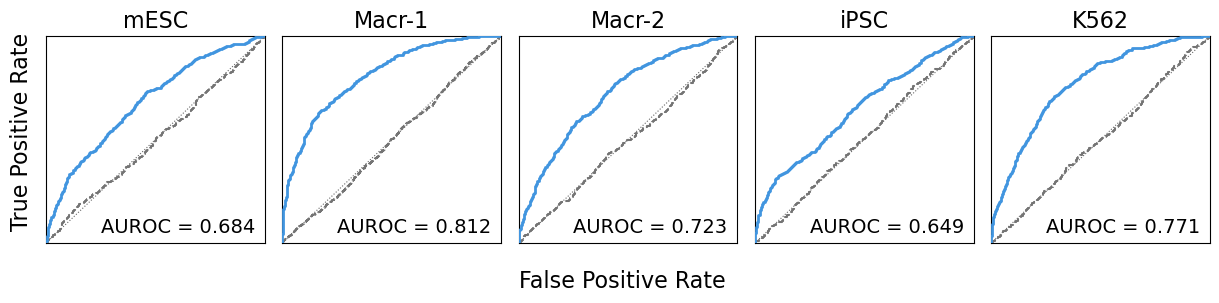

In [72]:
models_to_plot = ["E7.5_rep1", "buffer_1", "buffer_2", "WT_D13_rep1", "sample_1"]

sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(models_to_plot),
    figsize=(12, 3),
    sharex=True,
    sharey=True,
)

roc_line_color = "#4195df"
rand_line_color = "#747474"

for ax, selected_model in zip(combined_axes, models_to_plot):

    matching_titles = [
        title for title in all_plot_data.keys()
        if f"{selected_model} Model" in title and f"{selected_model} Test Set" in title
    ]

    if len(matching_titles) == 0:
        ax.axis("off")
        ax.set_title(f"{selected_model}\nMissing", fontsize=10)
        continue

    title = matching_titles[0]

    labels = all_plot_data[title][0]
    scores = all_plot_data[title][1]

    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)

    rand_scores = plotting_utils._create_random_distribution(scores)
    rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
    rand_auroc = roc_auc_score(labels, rand_scores)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        color=roc_line_color,
        label=f"AUROC = {auroc:.3f}",
        zorder=3,
    )

    ax.plot(
        rand_fpr,
        rand_tpr,
        color=rand_line_color,
        linestyle="--",
        lw=1.5,
        label=f"Random = {rand_auroc:.3f}",
        zorder=2,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle=":",
        lw=0.8,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title(sample_to_title_map.get(selected_model, selected_model), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.25,
        0.05,
        f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        fontsize=14,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# combined_fig.suptitle("Model vs Test Set", fontsize=14, y=1.05)

combined_fig.text(
    0.5,
    -0.02,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.5,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.13,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set.png", dpi=300, bbox_inches="tight")

In [15]:
def _create_random_distribution(scores, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    arr = np.asarray(scores)   # works for Series or ndarray, no copy if already ndarray
    return rng.uniform(arr.min(), arr.max(), size=arr.shape[0])

def _balance_pos_neg(labels, scores):
    true_scores = scores[labels == 1]
    false_scores = scores[labels == 0]
    
    n_pos = len(true_scores)
    n_neg = len(false_scores)
    
    if n_pos == 0 or n_neg == 0:
        raise ValueError("Both positive and negative examples are required for balancing.")
    
    if n_pos > n_neg:
        true_scores_balanced = np.random.choice(true_scores, size=n_neg, replace=False)
        false_scores_balanced = false_scores    
    elif n_neg > n_pos:
        false_scores_balanced = np.random.choice(false_scores, size=n_pos, replace=False)
        true_scores_balanced = true_scores
        
    balanced_labels = np.concatenate([np.ones_like(true_scores_balanced), np.zeros_like(false_scores_balanced)])
    balanced_scores = np.concatenate([true_scores_balanced, false_scores_balanced])
    
    # Shuffle the balanced dataset
    indices = np.arange(len(balanced_labels))
    np.random.shuffle(indices)
    balanced_labels = balanced_labels[indices]
    balanced_scores = balanced_scores[indices]
    
    return balanced_labels, balanced_scores

In [ ]:
model_samples = [
    "E7.5_rep1",
    "E7.5_rep2",
    "E8.5_rep1",
    "E8.5_rep2",
    "WT_D13_rep1",
    "buffer_1",
    "buffer_2",
    "buffer_3",
    "buffer_4",
    "sample_1",
]

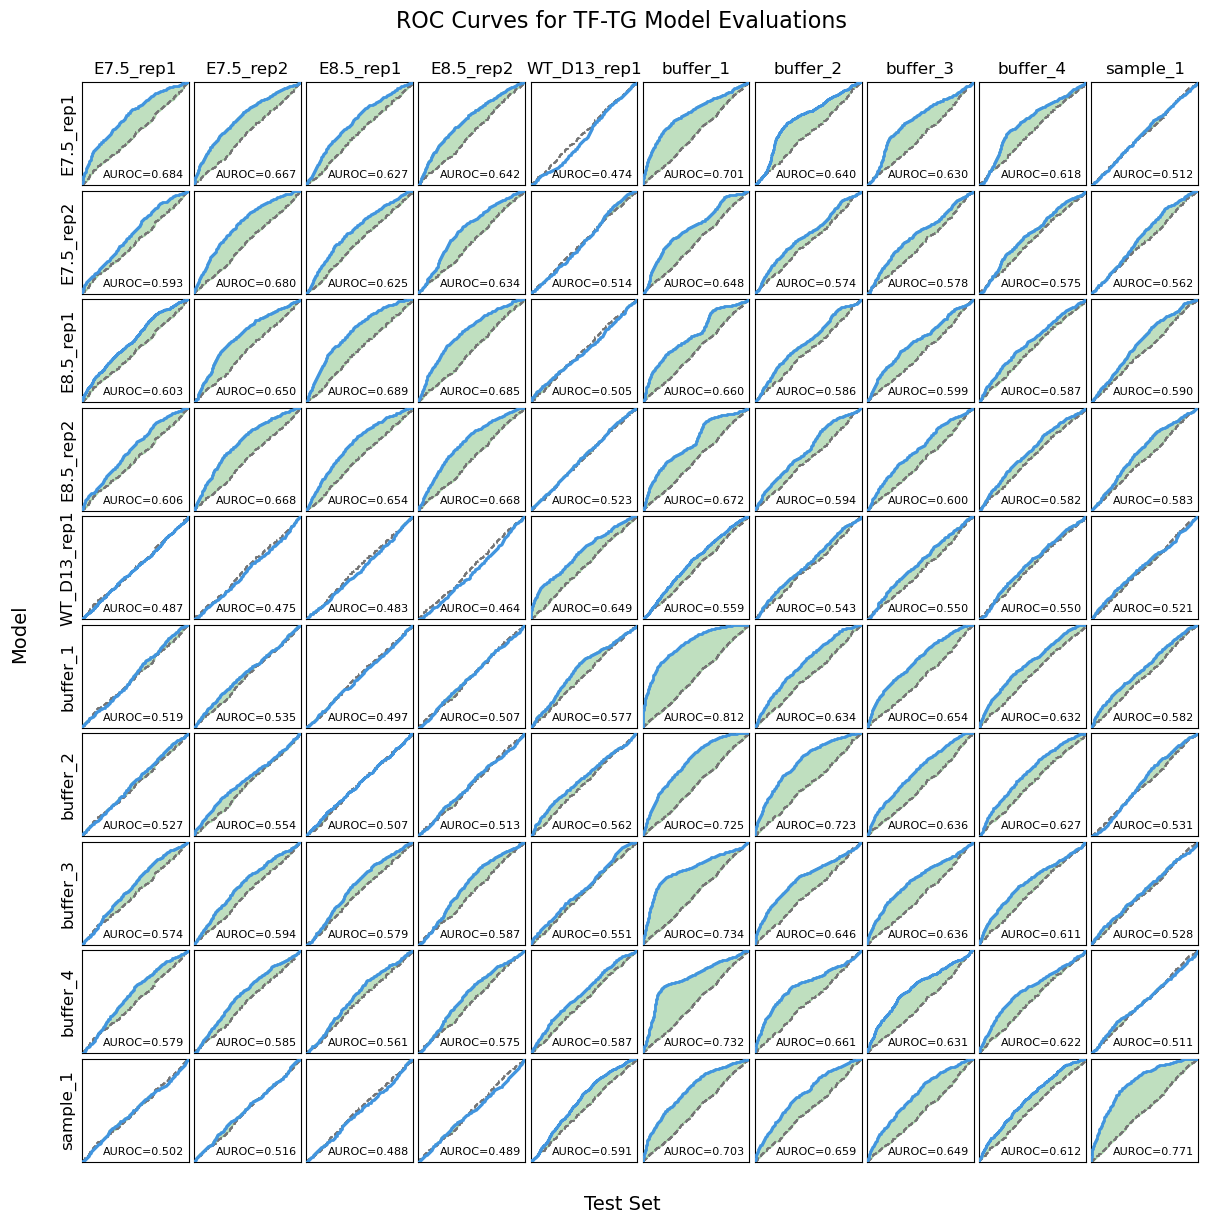

In [ ]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        rand_scores = _create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

        ax.plot(
            fpr,
            tpr,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random TPR onto model FPR grid
        rand_tpr_interp = np.interp(fpr, rand_fpr, rand_tpr)

        # Fill only where model ROC is above random ROC
        ax.fill_between(
            fpr,
            tpr,
            rand_tpr_interp,
            where=(tpr > rand_tpr_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.20,
            0.07,
            f"AUROC={auroc:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("ROC Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=14,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=14,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_roc_curves.png", dpi=300, bbox_inches="tight")


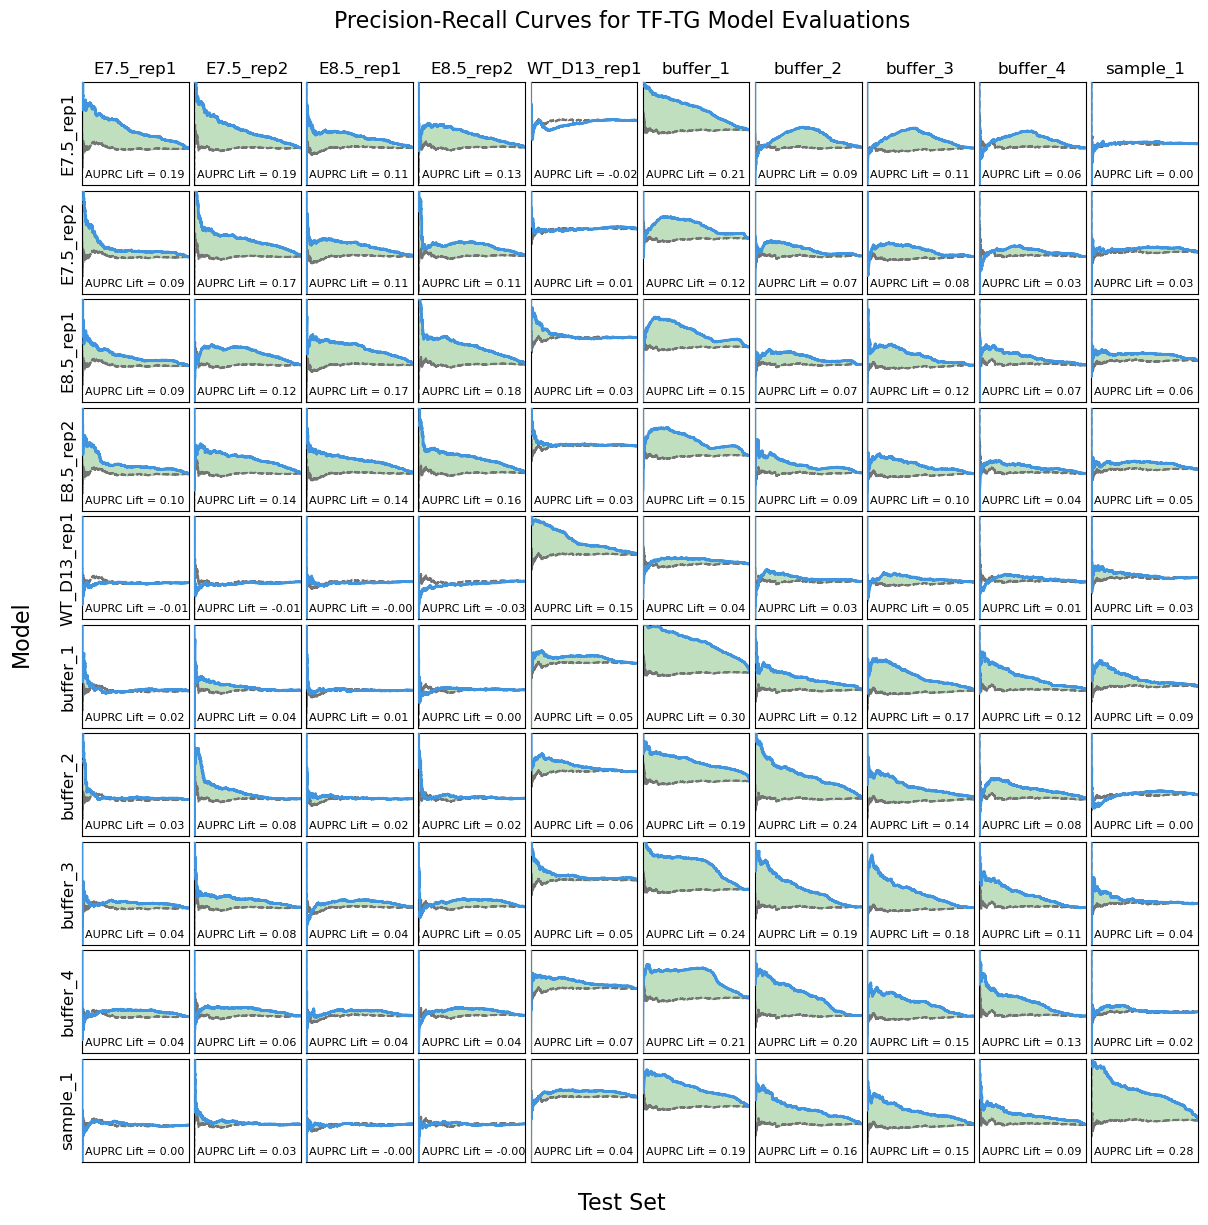

In [42]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        prec, rec, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_prec, rand_rec, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)
        
        auprc_lift = auprc - rand_auprc
        
        order = np.argsort(rand_rec)
        rand_rec_sorted = rand_rec[order]
        rand_prec_sorted = rand_prec[order]

        ax.plot(
            rec,
            prec,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_rec,
            rand_prec,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random recall onto model grid
        rand_prec_interp = np.interp(rec, rand_rec_sorted, rand_prec_sorted)

        # Fill only where model AUPRC is above random AUPRC
        ax.fill_between(
            rec,
            prec,
            rand_prec_interp,
            where=(prec > rand_prec_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.03,
            0.07,
            f"AUPRC Lift = {auprc_lift:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("Precision-Recall Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=16,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=16,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_pr_curves.png", dpi=300, bbox_inches="tight")


In [ ]:
# full_comparison_df["AUPRC Lift"] = full_comparison_df["auprc"] - full_comparison_df["rand_auprc"]

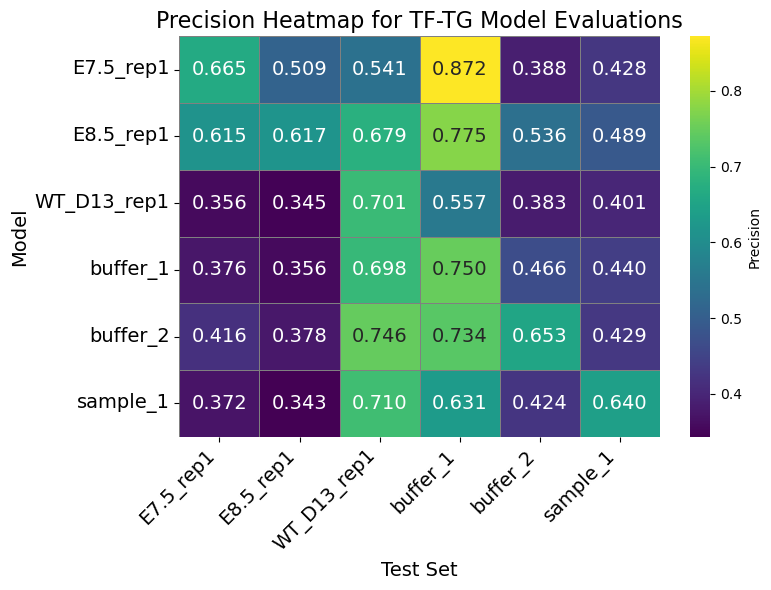

In [154]:
# Heatmap of AUROC values for each model vs test set combination
selected_metric = "Precision"
test_comparison_df = full_comparison_df.copy()

test_comparison_df = test_comparison_df.rename(columns={
    "auroc": "AUROC", 
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    })

test_comparison_df = test_comparison_df[["Model", "Test Set", selected_metric]]

test_comparison_df_pivot = test_comparison_df.pivot(index="Model", columns="Test Set", values=selected_metric)

fig = plt.figure(figsize=(8, 6))
heatmap_fig = sns.heatmap(
    test_comparison_df_pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': selected_metric},
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 14}
)
heatmap_fig.set_title(f"{selected_metric} Heatmap for TF-TG Model Evaluations", fontsize=16)
heatmap_fig.set_xlabel("Test Set", fontsize=14)
heatmap_fig.set_ylabel("Model", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
full_comparison_df

,Model,Test Set,auroc,auprc,accuracy,precision,recall,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.633998,0.494009,0.651,0.604167,0.080780,0.514729,0.374892
1,E7.5_rep1,E8.5_rep1,0.546187,0.405282,0.614,0.437500,0.131720,0.484787,0.366425
2,E7.5_rep1,WT_D13_rep1,0.547477,0.655097,0.373,0.500000,0.014354,0.490202,0.612224
3,E7.5_rep1,buffer_1,0.646212,0.625755,0.455,0.483871,0.027574,0.498194,0.548040
4,E7.5_rep1,buffer_2,0.573830,0.434362,0.614,0.400000,0.010417,0.548439,0.417309
5,E7.5_rep1,sample_1,0.515000,0.435138,0.552,0.428571,0.246377,0.505276,0.428748
6,E8.5_rep1,E7.5_rep1,0.589560,0.454657,0.645,0.600000,0.033426,0.537448,0.403017
7,E8.5_rep1,E8.5_rep1,0.636168,0.488269,0.631,0.513043,0.158602,0.475956,0.359367
8,E8.5_rep1,WT_D13_rep1,0.497420,0.623477,0.375,0.538462,0.022329,0.465227,0.601898
9,E8.5_rep1,buffer_1,0.656314,0.684073,0.490,0.750000,0.093750,0.491921,0.540080


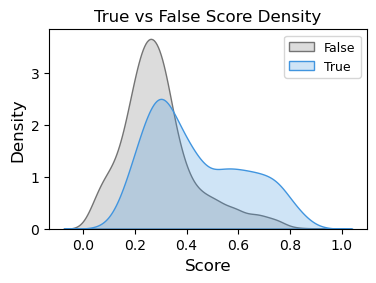

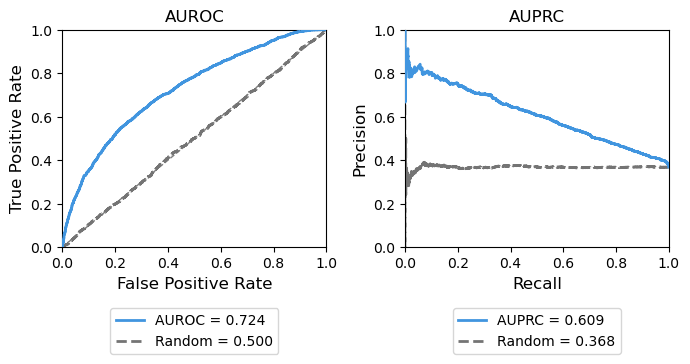

In [56]:
histogram_fig = plotting_utils.plot_score_histograms(
    labels=all_labels_flat,
    scores=all_scores_flat,
    n_bins=50,
    y_log=False,
    panel_kind="kde",
    density=False,
)
histogram_fig.show()

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
)
auroc_auprc_fig.show()

### Evaluate the predictions

In [45]:
importlib.reload(stat_utils)

<module 'stat_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/stat_utils.py'>

In [44]:
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df)

,Model,Test Set,auroc,auprc,accuracy,precision,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.696399,0.577159,0.6708,0.698347,0.519975,0.381786
1,E7.5_rep1,E8.5_rep1,0.621752,0.629031,0.5656,0.661054,0.501131,0.519073
2,E8.5_rep1,E7.5_rep1,0.636114,0.489747,0.6294,0.493907,0.526398,0.390878
3,E8.5_rep1,E8.5_rep1,0.690027,0.686342,0.6314,0.638061,0.494796,0.520802


## Testing model sizes through the network

In [82]:
evaluation_cell_type = "mESC"
model_training_sample = "E7.5_rep1"
evaluation_sample = "E7.5_rep1"

print(f"Model {model_training_sample} | Test set {evaluation_sample}")

tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[evaluation_cell_type]

# print(f"Loading TF→TG model")
dataset_split_type = "test"
subset_size = 5000

cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

# print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=dataset_split_type,
    subset_size=subset_size
    )

tf_tg_model = load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

# print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model

Model E7.5_rep1 | Test set E7.5_rep1


In [83]:
def shape_of(x):
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_of(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_of(v) for v in x]
    if x is None:
        return None
    return type(x).__name__


def make_shape_hook(name):
    def hook(module, args, kwargs, output):
        print(f"\n{name}")
        print(f"  args  : {shape_of(args)}")
        print(f"  module: {type(module).__name__}")
        print(f"  kwargs: {shape_of(kwargs)}")
        print(f"  output: {shape_of(output)}")
    return hook


model = tf_tg_model.model.to(device)
model.eval()

hook_names = {
    "tf_peak_model.tf_encoder",
    "tf_peak_model.peak_encoder",
    "tf_peak_model.cross_attn",
    "tf_peak_model.classifier",
    "peak_feature_proj",
    "tf_expr_proj",
    "tg_expr_proj",
    "tg_query_proj",
    "peak_attention",
    "norm",
    "classifier",
}

# Clear old hooks aggressively in notebook debugging
for module in model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

hooks = []
for name, module in model.named_modules():
    if name in hook_names:
        hooks.append(
            module.register_forward_hook(
                make_shape_hook(name),
                with_kwargs=True,
            )
        )
        
batch = next(iter(data_loader))
batch = tf_to_tg_module.move_batch_to_device(batch, device)

print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")

with torch.no_grad():
    edge_logits, aux_outputs = model(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=batch["cell_mask"],
        pooling_mode="lse",
        pooling_temperature=1.0,
    )

print("\nFinal outputs:")
print("  edge_logits:", tuple(edge_logits.shape))
print("  aux_outputs:", shape_of(aux_outputs))

for h in hooks:
    h.remove()


Batch input shapes:
  tf_embedding: (64, 5588, 128)
  tf_mask: (64, 5588)
  peak_sequences: (64, 8, 256, 4)
  peak_accessibility: (64, 16, 8)
  peak_distance: (64, 8)
  tf_expression: (64, 16)
  tg_expression: (64, 16)
  label: (64,)
  cell_mask: (64, 16)
  peak_mask: (64, 8)

tf_peak_model.tf_encoder
  args  : [(256, 5588, 128)]
  module: Sequential
  kwargs: {}
  output: (256, 5588, 128)

tf_peak_model.peak_encoder
  args  : [(256, 4, 256)]
  module: Sequential
  kwargs: {}
  output: (256, 128, 16)

tf_peak_model.cross_attn
  args  : []
  module: BidirectionalCrossAttentionTransformer
  kwargs: {'x': (256, 5588, 128), 'context': (256, 16, 128), 'mask': (256, 5588), 'context_mask': (256, 16)}
  output: [(256, 5588, 128), (256, 16, 128)]

tf_peak_model.classifier
  args  : [(256, 256)]
  module: Sequential
  kwargs: {}
  output: (256, 1)

tf_peak_model.tf_encoder
  args  : [(256, 5588, 128)]
  module: Sequential
  kwargs: {}
  output: (256, 5588, 128)

tf_peak_model.peak_encoder
  arg

In [58]:
print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")


Batch input shapes:
  tf_embedding: (64, 5588, 128)
  tf_mask: (64, 5588)
  peak_sequences: (64, 8, 256, 4)
  peak_accessibility: (64, 16, 8)
  peak_distance: (64, 8)
  tf_expression: (64, 16)
  tg_expression: (64, 16)
  label: (64,)
  cell_mask: (64, 16)
  peak_mask: (64, 8)


## Test model performance vs other inference methods

In [74]:
model_cell_type = "K562"
evaluation_sample = "sample_1"

### Load the cached test dataset to get the labels and gene name to index maps

In [75]:
def generate_model_predictions(model, data_loader, device, tf_idx_to_name, tg_idx_to_name):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            edge_logits, _ = model.forward(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                peak_distance=batch["peak_distance"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch.get("peak_mask", None),
                cell_mask=batch["cell_mask"],
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            scores = torch.sigmoid(edge_logits)

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

In [76]:
cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

# Load the cached test dataset
subset_size = 5000
split_type = "val"
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=split_type,
    subset_size=subset_size
    )

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

# Create the TF and TG index to name mappings
tftg_inputs_test = torch.load(
    cell_type_cache_dir / "tf_tg_training_cache" / evaluation_sample / f"tftg_inputs_{split_type}.pt",
    weights_only=False,
)


tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

test_set_tf_indices = list(tftg_inputs_test['tf_idx'].numpy())
test_set_tg_indices = list(tftg_inputs_test['tg_idx'].numpy())

test_set_tf_names_upper = [tf_idx_to_name[idx].upper() for idx in set(test_set_tf_indices)]
test_set_tg_names_upper = [tg_idx_to_name[idx].upper() for idx in set(test_set_tg_indices)]

### Load the TF-TG model and run model predictions on the labeled test set

In [77]:
tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][evaluation_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]

# Load the TF→TG model
tf_tg_model = load_tf_tg_regulation_model(
    tf_dna_model_chkpt, 
    tf_tg_model_chkpt, 
    tf_embeddings_tensor, 
    tf_mask_tensor
    )

# Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
prediction_df = generate_model_predictions(tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)
print(prediction_df.head())

Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:18<00:00,  4.25it/s]

  Source  Target     Score
0   ADNP  AKT1S1  0.621479
1   ADNP   BRME1  0.466764
2   ADNP  CAPN12  0.543302
3   ADNP   FCGRT  0.323494
4   ADNP  GAPDHS  0.156791


### Create the ground truth dataframe from the labeled test set

In [86]:
def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    positives = tf_tg_label_df["Label"].sum()
    negatives = len(tf_tg_label_df) - positives

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)

### Load the inferred GRNs for the other inference methods

In [79]:
def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

other_method_grns = {}
logging.info(f"\nProcessing sample: {evaluation_sample} | Dataset: {model_cell_type}")

linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{model_cell_type}_{evaluation_sample}.tsv"
scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{model_cell_type}_{evaluation_sample}.tsv"
cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{model_cell_type}_{evaluation_sample}.tsv"
pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{model_cell_type}_{evaluation_sample}.tsv"
figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{model_cell_type}_{evaluation_sample}.tsv"

method_info = {
    "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
}
        
standardized_method_dfs = {}
for method_name, info in method_info.items():
    logging.info(f"  - Loading {method_name}")
    df_std = load_and_standardize_method(method_name, info)
    
    df_std = df_std[df_std["Source"].isin(test_set_tf_names_upper)].copy()
    
    mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
    
    df_filtered = df_std.loc[mask]
    
    standardized_method_dfs[method_name] = df_std

INFO - 
Processing sample: sample_1 | Dataset: K562
INFO -   - Loading SCENIC+
INFO -   - Loading LINGER
INFO -   - Loading CellOracle
INFO -   - Loading Pando
INFO -   - Loading FigR


### Calculate the performance metrics for each inferred GRN

In [177]:
def compute_metrics(name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):    
    logging.info(f"    - After filtering to test set TFs, {len(df)} edges remain")
        
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
        auprc = np.nan
        rand_auroc = np.nan
        rand_auprc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)
        auprc = average_precision_score(labels, scores)

        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        rand_auroc = roc_auc_score(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

    return pd.DataFrame([{
        "method_name": name,
        "auroc": auroc,
        "auprc": auprc,
        "rand_auroc": rand_auroc,
        "rand_auprc": rand_auprc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])

# Add the TF-TG model predictions to the standardized_method_dfs for metric computation
standardized_method_dfs["TF-TG Model"] = prediction_df

inference_method_dfs = []
for method_name, df_std in standardized_method_dfs.items():
    logging.info(f"Computing metrics for {method_name}")
    df_metrics = compute_metrics(method_name, df_std, gt_pairs, score_threshold=0.5)
    df_metrics["Model"] = method_name
    df_metrics["Test Set"] = evaluation_sample
    inference_method_dfs.append(df_metrics)
    
inference_comparison_df = pd.concat(inference_method_dfs, ignore_index=True)
display(inference_comparison_df.T)

INFO - Computing metrics for SCENIC+
INFO -     - After filtering to test set TFs, 42910 edges remain
INFO - Computing metrics for LINGER
INFO -     - After filtering to test set TFs, 2629880 edges remain
INFO - Computing metrics for CellOracle
INFO -     - After filtering to test set TFs, 538814 edges remain
INFO - Computing metrics for Pando
INFO -     - After filtering to test set TFs, 43199 edges remain
INFO - Computing metrics for FigR
INFO -     - After filtering to test set TFs, 888389 edges remain
INFO - Computing metrics for TF-TG Model
INFO -     - After filtering to test set TFs, 5000 edges remain


,0,1,2,3,4,5
method_name,SCENIC+,LINGER,CellOracle,Pando,FigR,TF-TG Model
auroc,0.533091,0.596089,0.460239,0.463634,0.489349,0.747859
auprc,0.003555,0.006611,0.005978,0.006321,0.004637,0.642257
rand_auroc,0.526315,0.49766,0.505207,0.500186,0.503502,0.500988
rand_auprc,0.003877,0.005252,0.006997,0.006515,0.004791,0.399945
accuracy,0.996644,0.636281,0.993126,0.754855,0.970728,0.693
precision,0.0,0.00692,0.0,0.006041,0.00472,0.616693
recall,0.0,0.478862,0.0,0.219512,0.024886,0.587639
n_edges,42910,2629880,538814,43199,888389,5000
n_pos,144,13814,3704,287,4179,1974


In [178]:
display(inference_comparison_df.set_index("method_name").sort_values("auroc", ascending=False))

,auroc,auprc,rand_auroc,rand_auprc,accuracy,precision,recall,n_edges,n_pos,n_neg,score_threshold,Model,Test Set
method_name,,,,,,,,,,,,,
TF-TG Model,0.747859,0.642257,0.500988,0.399945,0.693000,0.616693,0.587639,5000,1974,3026,0.5,TF-TG Model,sample_1
LINGER,0.596089,0.006611,0.497660,0.005252,0.636281,0.006920,0.478862,2629880,13814,2616066,0.5,LINGER,sample_1
SCENIC+,0.533091,0.003555,0.526315,0.003877,0.996644,0.000000,0.000000,42910,144,42766,0.5,SCENIC+,sample_1
FigR,0.489349,0.004637,0.503502,0.004791,0.970728,0.004720,0.024886,888389,4179,884210,0.5,FigR,sample_1
Pando,0.463634,0.006321,0.500186,0.006515,0.754855,0.006041,0.219512,43199,287,42912,0.5,Pando,sample_1
CellOracle,0.460239,0.005978,0.505207,0.006997,0.993126,0.000000,0.000000,538814,3704,535110,0.5,CellOracle,sample_1


## Predictions per epoch

In [49]:
model_cell_type = "Macrophage"
model_training_sample = "buffer_1"

chkpt_dir = find_latest_checkpoint(model_cell_type, model_training_sample, training_number="3693277").parent
print(f"Using checkpoint directory: {chkpt_dir.name}")

chkpt_files = list(chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
if not chkpt_files:
    logging.warning(f"No checkpoint files found for {model_training_sample} in {chkpt_dir.name}")

chkpt_files.sort(key=lambda f: int(f.stem.split("-")[0].split("=")[1]), reverse=False)
chkpt_nums = [int(f.stem.split("-")[0].split("=")[1]) for f in chkpt_files]
print(f"Found {len(chkpt_files)} checkpoint files with epochs: {chkpt_nums[:2]} ... {chkpt_nums[-2:]}")

all_plot_data = {}
all_comparison_df_list = []
subset_size = 1000
for chkpt_file in tqdm(chkpt_files, desc="Evaluating Checkpoints", ncols=100):
    dataset_split_type = "test"
    
    epoch_num = int(chkpt_file.stem.split("-")[0].split("=")[1])
    
    tf_tg_model_checkpoints[model_cell_type][model_training_sample] = chkpt_file
    
    comparison_result = run_prediction_vs_test_set(
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=model_cell_type,
        evaluation_sample=model_training_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    metric_df["epoch"] = epoch_num
    
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = f"{model_cell_type} {model_training_sample}\nEpoch {epoch_num}"
    
    all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df.T)

INFO - Latest checkpoint for Macrophage buffer_1: Job 3693277 Epoch 249


Using checkpoint directory: tf_tg_train_buffer_1_3693277
Found 100 checkpoint files with epochs: [144, 149] ... [248, 249]


Evaluating Checkpoints: 100%|█████████████████████████████████████| 100/100 [10:56<00:00,  6.56s/it]


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Model,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,...,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1
Test Set,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,...,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1,buffer_1
auroc,0.827452,0.829774,0.829161,0.830407,0.832321,0.832769,0.831874,0.831689,0.830689,0.832265,...,0.830927,0.835385,0.83497,0.83601,0.833805,0.837344,0.836651,0.833632,0.836445,0.83809
auprc,0.8479,0.849681,0.850275,0.850053,0.852728,0.851862,0.85149,0.852333,0.851387,0.852851,...,0.849758,0.855555,0.856415,0.856669,0.853193,0.856894,0.855907,0.85403,0.856404,0.855924
accuracy,0.746,0.752,0.752,0.754,0.755,0.753,0.751,0.754,0.752,0.754,...,0.759,0.755,0.755,0.752,0.758,0.756,0.763,0.758,0.754,0.766
precision,0.776718,0.784615,0.791339,0.786538,0.780488,0.776536,0.7853,0.796813,0.778195,0.78327,...,0.797642,0.792564,0.782609,0.778195,0.789272,0.780899,0.801572,0.778598,0.781132,0.792453
recall,0.748162,0.75,0.738971,0.751838,0.764706,0.766544,0.746324,0.735294,0.761029,0.757353,...,0.746324,0.744485,0.761029,0.761029,0.757353,0.766544,0.75,0.775735,0.761029,0.772059
rand_auroc,0.517782,0.518378,0.522264,0.51995,0.52114,0.520495,0.521079,0.519987,0.520309,0.520382,...,0.518282,0.518644,0.520221,0.519318,0.518092,0.518386,0.519688,0.517044,0.518697,0.518866
rand_auprc,0.57333,0.573972,0.576058,0.576808,0.57499,0.574811,0.575829,0.574268,0.575522,0.575691,...,0.575014,0.572474,0.572905,0.572499,0.57206,0.572032,0.573754,0.57201,0.573001,0.575183
epoch,144,149,150,151,152,154,155,156,157,158,...,240,241,242,243,244,245,246,247,248,249


In [28]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [53]:
plot_dir = PROJECT_DIR / "plots" / "histogram_per_epoch" / f"{model_cell_type}_{model_training_sample}"
plot_dir.mkdir(parents=True, exist_ok=True)
(plot_dir / "epoch_figs").mkdir(parents=True, exist_ok=True)

for title in tqdm(all_plot_data.keys(), desc="Plotting Histograms", ncols=100):        
    labels = all_plot_data[title][0]
    scores = all_plot_data[title][1]
    
    epoch = int(title.split("\nEpoch ")[1])

    histogram_fig = plotting_utils.plot_score_histograms(
        labels=labels,
        scores=scores,
        n_bins=50,
        y_log=False,
        panel_kind="kde",
        density=False,
        title = title,
        y_lim=(0, 5),
        x_lim=(0, 1)
    )

    histogram_fig.savefig(plot_dir / "epoch_figs" / f"epoch_{epoch}.png")
    plt.close(histogram_fig)
    
# Combine all histogram plots into a GIF in epoch order
import imageio.v3 as iio
gif_path = plot_dir / f"{model_cell_type}_{model_training_sample}_histograms.gif"

filenames = sorted(plot_dir.glob("epoch_figs/epoch_*.png"), key=lambda f: int(f.stem.split("_")[1]))
images = [iio.imread(str(f)) for f in filenames]

default_duration = 200
# The lagging
lag = 2000
# Pause the GIF by extending the duration of the last frame
duration = [default_duration] * (len(images)-1) + [lag]
iio.imwrite(gif_path, images, duration=duration, loop=0)
            

Plotting Histograms:   0%|                                                  | 0/100 [00:00<?, ?it/s]

Plotting Histograms: 100%|████████████████████████████████████████| 100/100 [00:10<00:00,  9.15it/s]


## Plot AUROC model vs self test set with other inference methods

In [118]:
samples_to_run = [
    ("mESC", "E7.5_rep1"),
    ("Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2"),
    ("K562", "sample_1"),
    ("iPSC", "WT_D13_rep1"),
]

label_by_method_dict = {}
score_by_method_dict = {}

subset_size = 5000

for model_cell_type, sample_name in samples_to_run:
    
    logging.info(f"\nProcessing sample: {sample_name} | Dataset: {model_cell_type}")
    
    cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

    use_val = ["sample_1"]
    if sample_name in use_val:
        split_type = "val"
    else:
        split_type = "test"
    
    # Load the cached test dataset
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=sample_name,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=split_type,
        subset_size=subset_size
        )

    # Create the TF and TG index to name mappings
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

    test_set_tf_indices = list(tftg_inputs_test['tf_idx'].numpy())
    test_set_tg_indices = list(tftg_inputs_test['tg_idx'].numpy())

    test_set_tf_names_upper = [tf_idx_to_name[idx].upper() for idx in set(test_set_tf_indices)]
    test_set_tg_names_upper = [tg_idx_to_name[idx].upper() for idx in set(test_set_tg_indices)]

    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]

    # Load the TF→TG model
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    prediction_df = generate_model_predictions(tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)

    # Create the labeled ground truth DataFrame for the test set
    tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)

    OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

    other_method_grns = {}

    linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{model_cell_type}_{sample_name}.tsv"
    scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
    cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{model_cell_type}_{sample_name}.tsv"
    pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{model_cell_type}_{sample_name}.tsv"
    figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{model_cell_type}_{sample_name}.tsv"

    method_info = {
        "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    }
            
    standardized_method_dfs = {}
    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)
        
        df_std = df_std[df_std["Source"].isin(test_set_tf_names_upper)].copy()
        
        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
        
        df_filtered = df_std.loc[mask]
        
        standardized_method_dfs[method_name] = df_std
        
    # Add the TF-TG model predictions to the standardized_method_dfs for metric computation
    standardized_method_dfs["TF-TG Classifier"] = prediction_df

    label_by_method_dict[sample_name] = {}
    score_by_method_dict[sample_name] = {}

    # Compute metrics for each method and print results
    for method_name, df in standardized_method_dfs.items():
        labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        scores = df["Score"].tolist()
        
        label_by_method_dict[sample_name][method_name] = labels
        score_by_method_dict[sample_name][method_name] = scores

INFO - 
Processing sample: E7.5_rep1 | Dataset: mESC


Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:25<00:00,  3.11it/s]
INFO - 
Processing sample: buffer_1 | Dataset: Macrophage
Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:26<00:00,  3.03it/s]
INFO - 
Processing sample: buffer_2 | Dataset: Macrophage
Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:17<00:00,  4.49it/s]
INFO - 
Processing sample: sample_1 | Dataset: K562
Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:17<00:00,  4.47it/s]
INFO - 
Processing sample: WT_D13_rep1 | Dataset: iPSC
Evaluating: 100%|███████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.72it/s]


### Plot ROC curves

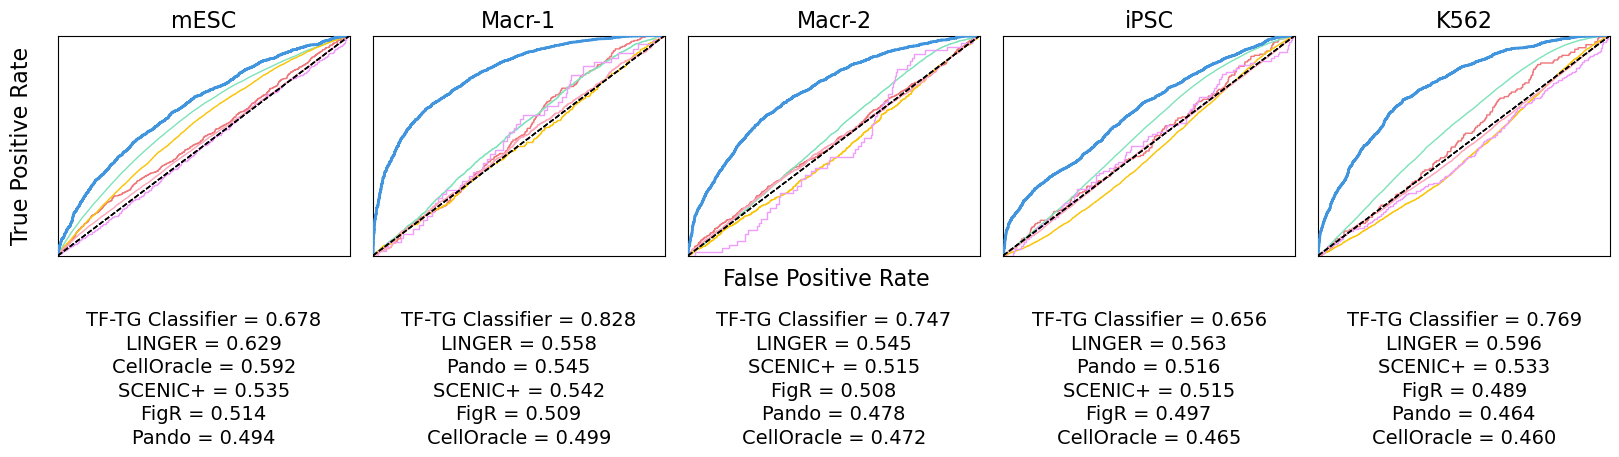

In [119]:
sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

method_color_dict = {
  "TF-TG Classifier": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

for ax, sample_name in zip(combined_axes, sample_to_title_map.keys()):
    
    auroc_text_lines = []
    
    for method in label_by_method_dict[sample_name].keys():
        labels = label_by_method_dict[sample_name][method]
        scores = score_by_method_dict[sample_name][method]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        rand_scores = plotting_utils._create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
        rand_auroc = roc_auc_score(labels, rand_scores)
        
        auroc_text_lines.append(f"{method} = {auroc:.3f}")

        if method == "TF-TG Classifier":
            line_weight = 2
            
        else:
            line_weight = 1
            
        roc_line_color = method_color_dict.get(method, roc_line_color)

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=roc_line_color,
            label=f"{method} = {auroc:.3f}",
            zorder=3,
        )
        
        ax.plot(
            [0, 1],
            [0, 1],
            color="black",
            linestyle="--",
            lw=1,
            alpha=0.6,
            zorder=4,
        )

        
    auroc_text_lines_sorted = sorted(auroc_text_lines, key=lambda s: float(s.split(" = ")[1]), reverse=True)
        

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Display AUROC scores below each plot
    ax.text(
        0.5,
        -0.25,
        "\n".join(auroc_text_lines_sorted),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
        linespacing=1.3,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

combined_fig.text(
    0.5,
    0.32,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.60,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.38,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set_roc.png", dpi=300, bbox_inches="tight")

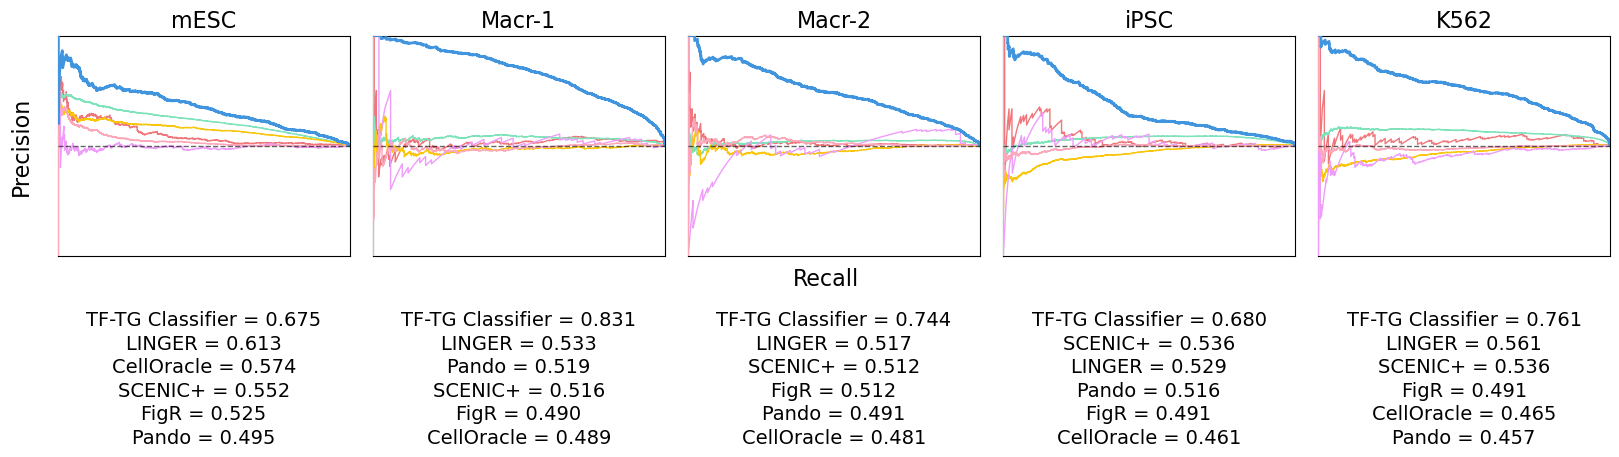

In [ ]:
combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

for ax, sample_name in zip(combined_axes, sample_to_title_map.keys()):
    
    auprc_text_lines = []
    
    for method in label_by_method_dict[sample_name].keys():
        labels = label_by_method_dict[sample_name][method]
        scores = score_by_method_dict[sample_name][method]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()
        
        balanced_labels, balanced_scores = plotting_utils._balance_pos_neg(labels, scores)

        prec, rec, _ = precision_recall_curve(balanced_labels, balanced_scores)
        auprc = average_precision_score(balanced_labels, balanced_scores)

        rand_scores = plotting_utils._create_random_distribution(balanced_scores)
        rand_prec, rand_rec, _ = precision_recall_curve(balanced_labels, rand_scores)
        rand_auprc = average_precision_score(balanced_labels, rand_scores)
        
        auprc_text_lines.append(f"{method} = {auprc:.3f}")

        if method == "TF-TG Classifier":
            line_weight = 2
        else:
            line_weight = 1
            
        prc_line_color = method_color_dict.get(method, "#747474")

        ax.plot(
            rec,
            prec,
            lw=line_weight,
            color=prc_line_color,
            label=f"{method} = {auprc:.3f}",
            zorder=3,
        )
        
    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda s: float(s.split(" = ")[1]),
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Display AUPRC scores below each plot
    ax.text(
        0.5,
        -0.25,
        "\n".join(auprc_text_lines_sorted),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
        linespacing=1.3,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    ax.plot(
        [0, 1],
        [0.5, 0.5],
        color="black",
        linestyle="--",
        lw=1,
        alpha=0.6,
        zorder=4,
    )

combined_fig.text(
    0.5,
    0.32,
    "Recall",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.60,
    "Precision",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.38,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_prc.png",
    dpi=300,
    bbox_inches="tight",
)